# This is for my calculations, this was not a programming problem

In [33]:
import matplotlib.pyplot as plt
from cachetools import cached
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import math

In [14]:
X = (0.3, 0.2, 0.5)
COUNT = 100

In [20]:
@cached({})
def get_sampling_distribution(n: int):
    if n == 1:
        return {
            1: 0.3,
            2: 0.2,
            3: 0.5
        }
    
    last = get_sampling_distribution(n - 1)
    ans = {}
    for k, v in last.items():
        for i in range(3):
            sum_of_sample = k * (n - 1) + i + 1
            prob = v * X[i]
            mean = sum_of_sample / n

            ans[mean] = ans.get(mean, 0) + prob
    return ans
print(get_sampling_distribution(2))

{1.0: 0.09, 1.5: 0.12, 2.0: 0.33999999999999997, 2.5: 0.2, 3.0: 0.25}


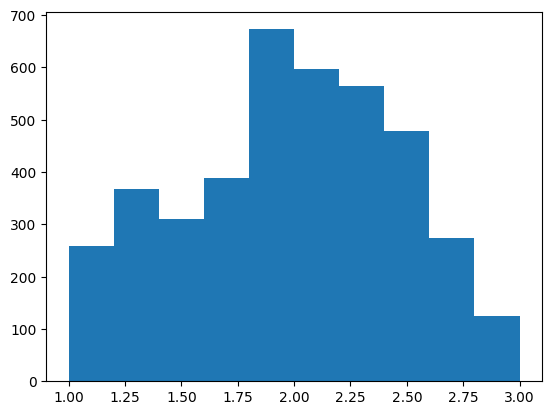

In [16]:
plt.hist(get_sampling_distribution(COUNT))
print()

Text(0, 0.5, 'variance')

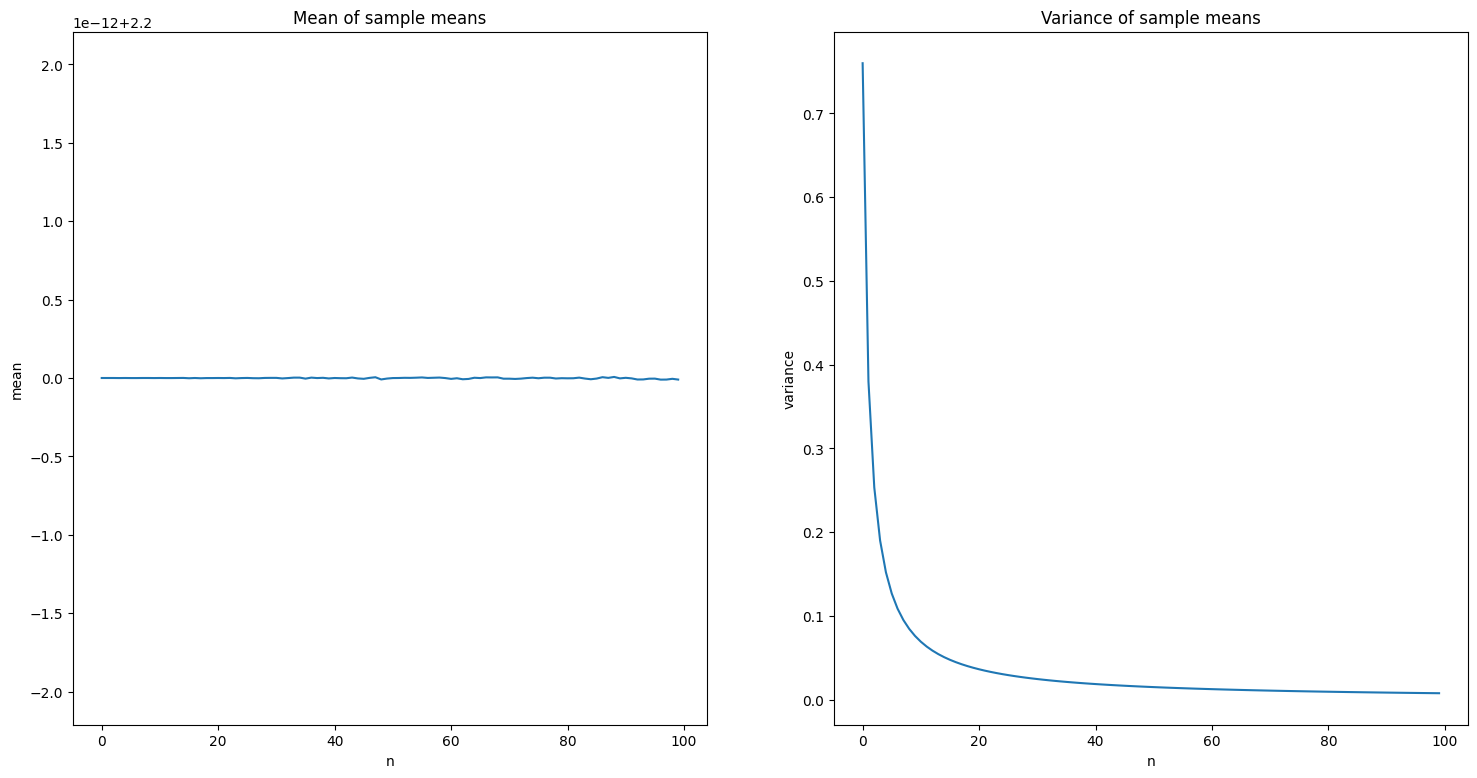

In [25]:
def calc_mean(dist: dict):
    ans = 0
    for k, v in dist.items():
        ans += k * v
    return ans 
def calc_variance(dist: dict):
    ans = 0
    mean = calc_mean(dist)
    for k, v in dist.items():
        ans += (k - mean)**2 * v
    return ans 

variances = []
means = []
for i in range(COUNT):
    mean = calc_mean(get_sampling_distribution(i + 1) )
    var = calc_variance(get_sampling_distribution(i + 1))
    variances.append(var)
    means.append(mean)

plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plt.title("Mean of sample means")
plt.plot(means)
plt.xlabel("n")
plt.ylabel("mean")

plt.subplot(1, 2, 2)
plt.title("Variance of sample means")
plt.plot(variances)
plt.xlabel("n")
plt.ylabel("variance")